<h1 align="center" id="top"><u>Pokemon classification</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ</u></h3>

# Table of Contents
***
1. [Import](#import)

## Import
***

In [3]:
from __future__ import annotations

from pathlib import Path

from bbox import bbox_by_saliency
from delete_background_grabcut import bbox_and_cutout
from delete_background_sobel import remove_background_inside_bbox_sobel

from preprocessing import preprocessing
from utils import build_dataframe, load_image, show_image

Let's now load the dataset using pandas (mapping the images path with their respective pokemon)

In [4]:
data_dir = Path.cwd().resolve().parents[0] / "data" / "fanart-dataset"

fanart_df = build_dataframe(data_dir)

print("\nTotal images:", len(fanart_df))
print("Total Pokémon:", fanart_df["pokemon"].nunique())
print("\n20 most present pokemon:")
print(fanart_df["pokemon"].value_counts().head(20))


Total images: 2717
Total Pokémon: 617

20 most present pokemon:
pokemon
gengar       26
bulbasaur    25
greninja     25
mewtwo       25
rayquaza     25
umbreon      25
suicune      24
giratina     23
solgaleo     23
sylveon      22
arcanine     21
gyarados     21
lugia        21
ninetales    21
blastoise    20
leafeon      20
primarina    20
scizor       20
eevee        19
lunala       19
Name: count, dtype: int64


Now let's filter a bit our dataset so that we only keep pokemons with a sufficient number of images

In [5]:
MIN_PER_CLASS = 15
counts = fanart_df["pokemon"].value_counts()
keep = counts[counts >= MIN_PER_CLASS].index
fanart_df_filtered = fanart_df[fanart_df["pokemon"].isin(keep)].reset_index(drop=True)

print("After filter:")
print("Total images:", len(fanart_df_filtered))
print("Total Pokémon:", fanart_df_filtered["pokemon"].nunique())
print(fanart_df_filtered["pokemon"].value_counts().head(10))

After filter:
Total images: 710
Total Pokémon: 36
pokemon
gengar       26
bulbasaur    25
greninja     25
mewtwo       25
rayquaza     25
umbreon      25
suicune      24
giratina     23
solgaleo     23
sylveon      22
Name: count, dtype: int64


In [6]:
fanart_df_filtered

,path,pokemon
0,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,aggron
1,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,aggron
2,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,aggron
3,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,aggron
4,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,aggron
...,...,...
705,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zoroark
706,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zoroark
707,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zoroark
708,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zoroark


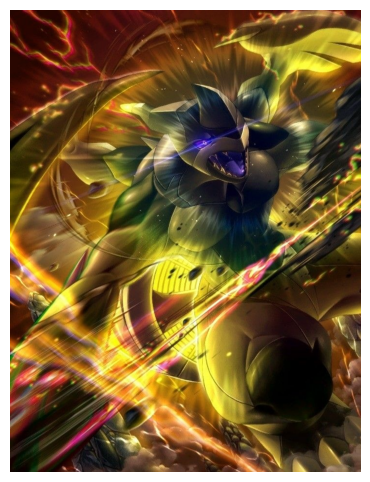

In [7]:
im = load_image(Path(fanart_df_filtered["path"][3]))
show_image(im)

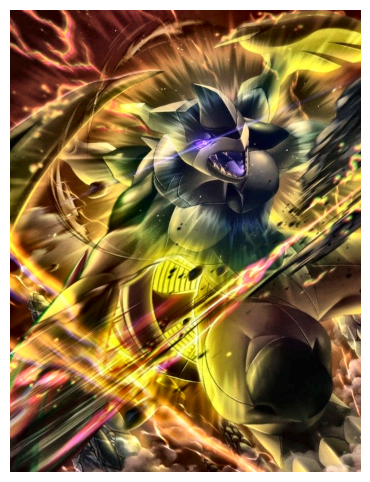

In [8]:
new_im = preprocessing(im)
show_image(new_im)

### Test bounding boxes pour isoler les pokemons avec opencv

Grabcut:

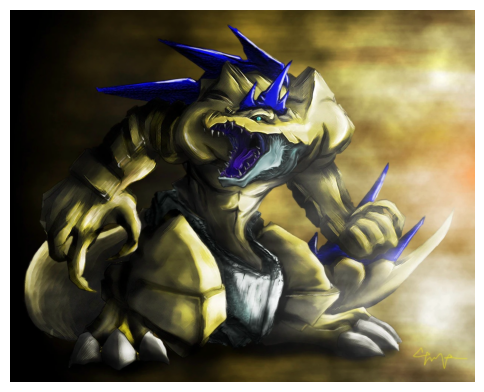

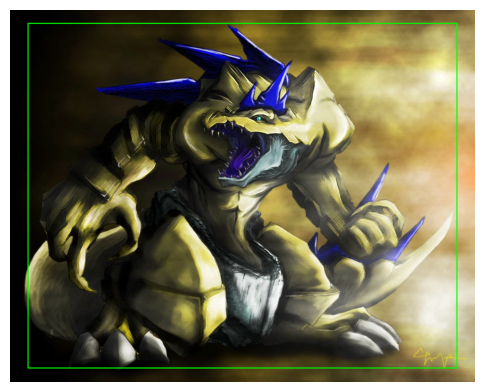

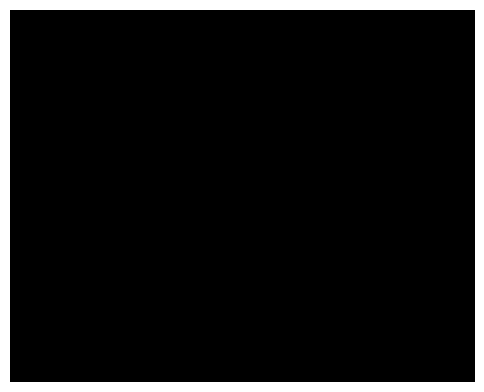

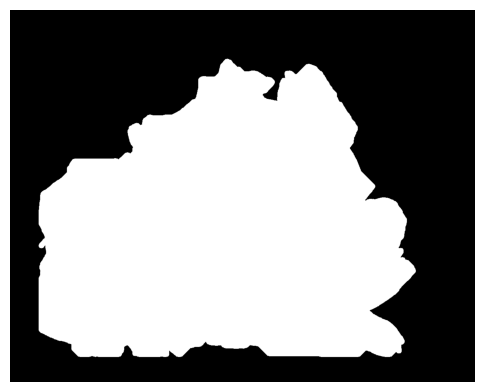

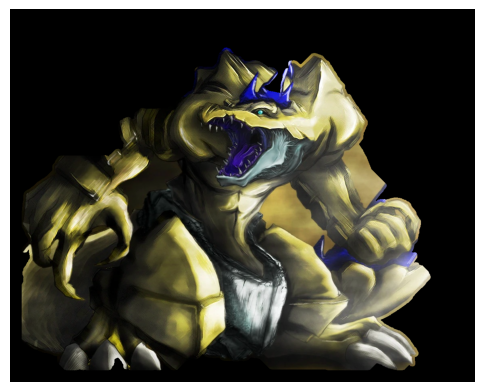

In [9]:
im = load_image(Path(fanart_df_filtered["path"][10]))
show_image(im)

cut_bgr, cut_rgba, bbox, dbg = bbox_and_cutout(
    im,
    pad_ratio=0.10,
    gc_iters=5,
    debug=True,
)

show_image(dbg["vis"])
show_image(dbg["mask"])
show_image(dbg["fg_mask_full"])
show_image(cut_bgr)

Sobel:

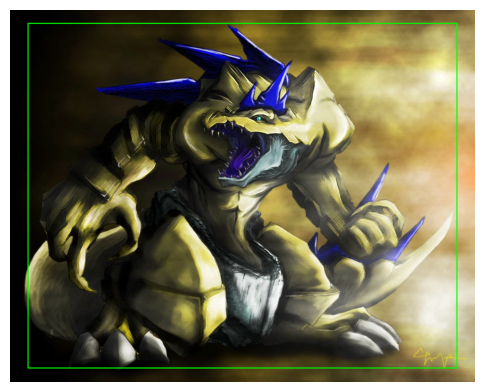

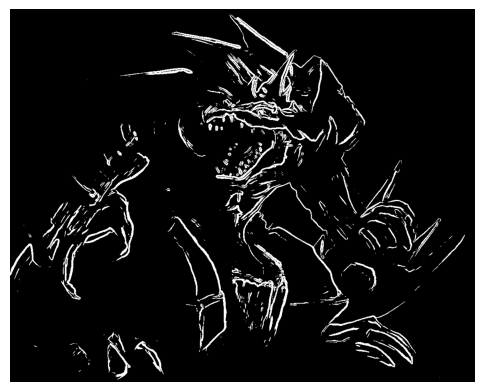

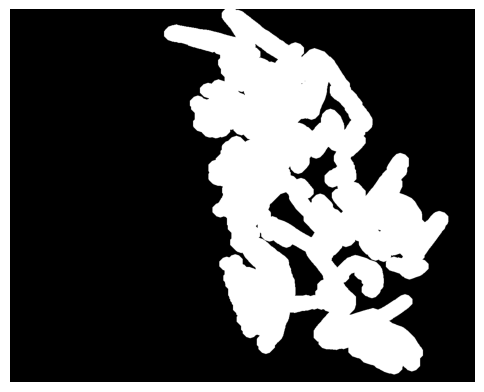

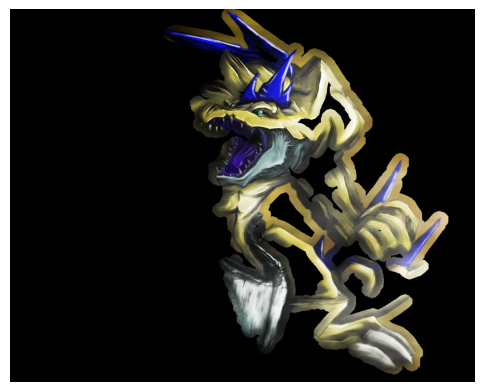

In [10]:
im = load_image(Path(fanart_df_filtered["path"][10]))

crop, bbox, dbg_bbox = bbox_by_saliency(im, pad_ratio=0.10, debug=True)

fg_mask_full, cut_bgr, cut_rgba, dbg = remove_background_inside_bbox_sobel(
    im,
    bbox,
    pad_mask_dilate=2,
    debug=True,
)

# visualiser
show_image(dbg_bbox["vis"])  # bbox
show_image(dbg["edges"])  # contours
show_image(dbg["keep_roi"])  # masque final dans la bbox
show_image(cut_bgr[bbox[1] : bbox[1] + bbox[3], bbox[0] : bbox[0] + bbox[2]])  # cutout crop